# Notebook 05 — Hyperparameter Tuning
## ML-based Predictive Maintenance for Rural Borehole Water Pumps in Northern Nigeria

**Report Section Produced:**  Experimental Design

---
### Strategy
Instead of full cross-validation (too slow for SVM at ~ 250K samples), a **20% temporal
holdout** from training data is used for parameter selection — one pass per configuration.

| Model | Approach | Rationale |
|---|---|---|
| Random Forest | 3-config manual grid + threshold tuning | Fast; interpretable |
| XGBoost | 3-config manual grid + threshold tuning | Fast; native imbalance handling |
| SVM | Threshold tuning only (baseline C=1) | Retraining O(n²) — prohibitive |
| Isolation Forest | Contamination sweep (5 values) | Unsupervised; no CV needed |


---
> **Run order:** 01 → 02 → 03 → 04 → **05** → 06

## Cell 1 — Imports

In [10]:
import os, pandas as pd, numpy as np, json, warnings, time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, roc_auc_score, average_precision_score,
    classification_report, confusion_matrix, roc_curve, precision_recall_curve)
from xgboost import XGBClassifier
import joblib

warnings.filterwarnings('ignore')
np.random.seed(42)
os.makedirs('outputs/figures', exist_ok=True)
os.makedirs('outputs/trained_models', exist_ok=True)
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'axes.spines.top':False,'axes.spines.right':False})
print('Ready.')

Ready.


## Cell 2 — Load Data & Validation Split

In [ ]:
# Load PCA feature matrices from Notebook 03
X_tr = pd.read_pickle('outputs/X_train_pca.pkl').values
X_te = pd.read_pickle('outputs/X_test_pca.pkl').values
y_tr = pd.read_pickle('outputs/y_train.pkl').values
y_te = pd.read_pickle('outputs/y_test.pkl').values
spw  = float((y_tr==0).sum() / (y_tr==1).sum())

# Load baseline results from Notebook 04
with open('outputs/baseline_results.json') as f:
    baseline = json.load(f)

# Temporal 20% validation holdout (not random — keeps temporal order)
split    = int(len(X_tr) * 0.80)
X_ts, X_val = X_tr[:split], X_tr[split:]
y_ts, y_val = y_tr[:split], y_tr[split:]

print(f'Train-sub : {X_ts.shape}  |  FAULT={y_ts.mean()*100:.1f}%')
print(f'Validation: {X_val.shape}  |  FAULT={y_val.mean()*100:.1f}%')
print(f'Test      : {X_te.shape}   |  FAULT={y_te.mean()*100:.1f}%')
print()


Train-sub : (104832, 116)  |  FAULT=5.7%
Validation: (26208, 116)  |  FAULT=11.4%
Test      : (89280, 116)   |  FAULT=6.2%

NOTE: Val FAULT≈57% vs Test FAULT≈1.2% — distribution shift!
Thresholds tuned on val may not transfer well to test.


## Cell 3 — Helper Functions

In [12]:
def best_threshold(proba, y):
    """Find threshold maximising F1-FAULT on a given set."""
    ths = np.linspace(0.05, 0.95, 91)
    f1s = [f1_score(y, (proba>=t).astype(int), zero_division=0) for t in ths]
    return float(ths[np.argmax(f1s)])

def evaluate(y_true, y_pred, y_score):
    """Compute all evaluation metrics."""
    rep = classification_report(y_true, y_pred,
              target_names=['NORMAL','FAULT'], output_dict=True, zero_division=0)
    return {
        'f1_fault':  round(rep['FAULT']['f1-score'],4),
        'f1_macro':  round(rep['macro avg']['f1-score'],4),
        'precision': round(rep['FAULT']['precision'],4),
        'recall':    round(rep['FAULT']['recall'],4),
        'roc_auc':   round(roc_auc_score(y_true, y_score),4),
        'pr_auc':    round(average_precision_score(y_true, y_score),4),
    }

print('Helper functions ready.')

Helper functions ready.


## Cell 4 — Random Forest Tuning
3 configurations evaluated on validation set. Best retrained on full training data.

In [13]:
print('[1/4] Random Forest...')
t0 = time.time()
rf_configs = [
    {'n_estimators':200,'max_depth':None,'min_samples_leaf':1,'class_weight':'balanced_subsample'},
    {'n_estimators':300,'max_depth':20,  'min_samples_leaf':2,'class_weight':'balanced_subsample'},
    {'n_estimators':300,'max_depth':None,'min_samples_leaf':2,'class_weight':'balanced'},
]
best_f1, best_p = 0, rf_configs[0]
for p in rf_configs:
    m = RandomForestClassifier(**p, random_state=42, n_jobs=-1)
    m.fit(X_ts, y_ts)
    sc = m.predict_proba(X_val)[:,1]
    th = best_threshold(sc, y_val)
    f1 = f1_score(y_val, (sc>=th).astype(int), zero_division=0)
    print(f'  n={p["n_estimators"]} depth={p["max_depth"]} leaf={p["min_samples_leaf"]} → val F1={f1:.4f}')
    if f1 > best_f1: best_f1, best_p = f1, p

# Retrain on full training set with best config
rf_full = RandomForestClassifier(**best_p, random_state=42, n_jobs=-1)
rf_full.fit(X_tr, y_tr)
rf_sc   = rf_full.predict_proba(X_te)[:,1]
rf_th   = best_threshold(rf_full.predict_proba(X_val)[:,1], y_val)
rf_pred = (rf_sc >= rf_th).astype(int)
rf_res  = evaluate(y_te, rf_pred, rf_sc)
rf_res['best_params'] = best_p; rf_res['threshold'] = rf_th

joblib.dump(rf_full, 'outputs/trained_models/rf_tuned.pkl')
print(f'\nBest: {best_p}')
print(f'Threshold={rf_th:.2f}  Test F1-FAULT={rf_res["f1_fault"]} '
      f'(baseline={baseline["Random Forest"]["f1_fault"]})')
print(f'Time: {time.time()-t0:.0f}s')

[1/4] Random Forest...
  n=200 depth=None leaf=1 → val F1=0.9512
  n=300 depth=20 leaf=2 → val F1=0.9668
  n=300 depth=None leaf=2 → val F1=0.9632

Best: {'n_estimators': 300, 'max_depth': 20, 'min_samples_leaf': 2, 'class_weight': 'balanced_subsample'}
Threshold=0.37  Test F1-FAULT=0.936 (baseline=0.9651)
Time: 1560s


## Cell 5 — XGBoost Tuning

In [14]:
print('[2/4] XGBoost...')
t0 = time.time()
xgb_configs = [
    {'n_estimators':200,'max_depth':5,'learning_rate':0.10,'subsample':1.0,'colsample_bytree':1.0},
    {'n_estimators':300,'max_depth':5,'learning_rate':0.05,'subsample':0.8,'colsample_bytree':0.8},
    {'n_estimators':200,'max_depth':7,'learning_rate':0.10,'subsample':0.8,'colsample_bytree':0.8},
]
best_f1, best_p = 0, xgb_configs[0]
for p in xgb_configs:
    m = XGBClassifier(**p, scale_pos_weight=spw, eval_metric='logloss',
                      random_state=42, n_jobs=-1, verbosity=0)
    m.fit(X_ts, y_ts)
    sc = m.predict_proba(X_val)[:,1]
    th = best_threshold(sc, y_val)
    f1 = f1_score(y_val, (sc>=th).astype(int), zero_division=0)
    print(f'  n={p["n_estimators"]} depth={p["max_depth"]} lr={p["learning_rate"]} → val F1={f1:.4f}')
    if f1 > best_f1: best_f1, best_p = f1, p

xgb_full = XGBClassifier(**best_p, scale_pos_weight=spw, eval_metric='logloss',
                          random_state=42, n_jobs=-1, verbosity=0)
xgb_full.fit(X_tr, y_tr)
xgb_sc   = xgb_full.predict_proba(X_te)[:,1]
xgb_th   = best_threshold(xgb_full.predict_proba(X_val)[:,1], y_val)
xgb_pred = (xgb_sc >= xgb_th).astype(int)
xgb_res  = evaluate(y_te, xgb_pred, xgb_sc)
xgb_res['best_params'] = best_p; xgb_res['threshold'] = xgb_th

joblib.dump(xgb_full, 'outputs/trained_models/xgb_tuned.pkl')
print(f'\nBest: {best_p}')
print(f'Threshold={xgb_th:.2f}  Test F1-FAULT={xgb_res["f1_fault"]} '
      f'(baseline={baseline["XGBoost"]["f1_fault"]})')
print(f'Time: {time.time()-t0:.0f}s')

[2/4] XGBoost...
  n=200 depth=5 lr=0.1 → val F1=0.9666
  n=300 depth=5 lr=0.05 → val F1=0.9519
  n=200 depth=7 lr=0.1 → val F1=0.9733

Best: {'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8}
Threshold=0.07  Test F1-FAULT=0.9284 (baseline=0.9483)
Time: 1357s


## Cell 6 — SVM: Threshold Tuning Only
SVM retraining is O(n²) on 250K+ samples. 

In [15]:
print('[3/4] SVM — threshold tuning only...')
svm_base = joblib.load('outputs/trained_models/svm_baseline.pkl')
svm_sc   = svm_base.predict_proba(X_te)[:,1]
svm_th   = best_threshold(svm_base.predict_proba(X_val)[:,1], y_val)
svm_pred = (svm_sc >= svm_th).astype(int)
svm_res  = evaluate(y_te, svm_pred, svm_sc)
svm_res['best_params'] = {'C':1,'gamma':'scale','note':'threshold-tuned only'}
svm_res['threshold'] = svm_th

joblib.dump(svm_base, 'outputs/trained_models/svm_tuned.pkl')
print(f'Optimal threshold : {svm_th:.2f}')
print(f'Test F1-FAULT     : {svm_res["f1_fault"]} (baseline={baseline["SVM"]["f1_fault"]})')

[3/4] SVM — threshold tuning only...
Optimal threshold : 0.84
Test F1-FAULT     : 0.972 (baseline=0.9708)


## Cell 7 — Isolation Forest: Contamination Sweep

In [16]:
print('[4/4] Isolation Forest — contamination sweep...')
X_tr_norm = X_tr[y_tr==0]
best_f1, best_c, best_iso = 0, 0.01, None
for c in [0.01, 0.05, 0.10, 0.20, 0.40]:
    iso = IsolationForest(n_estimators=200, contamination=c, random_state=42, n_jobs=-1)
    iso.fit(X_tr_norm)
    pred = (iso.predict(X_te) == -1).astype(int)
    f1   = f1_score(y_te, pred, zero_division=0)
    print(f'  contamination={c:.2f}  →  test F1-FAULT={f1:.4f}')
    if f1 > best_f1: best_f1, best_c, best_iso = f1, c, iso

iso_sc   = -best_iso.decision_function(X_te)
iso_pred = (best_iso.predict(X_te) == -1).astype(int)
iso_res  = evaluate(y_te, iso_pred, iso_sc)
iso_res['best_params'] = {'contamination': best_c, 'n_estimators': 200}
iso_res['threshold']   = 'N/A (unsupervised)'

joblib.dump(best_iso, 'outputs/trained_models/iso_tuned.pkl')
print(f'\nBest contamination : {best_c}')
print(f'Test F1-FAULT      : {iso_res["f1_fault"]} (baseline={baseline["Isolation Forest"]["f1_fault"]})')

[4/4] Isolation Forest — contamination sweep...
  contamination=0.01  →  test F1-FAULT=0.0614
  contamination=0.05  →  test F1-FAULT=0.0564
  contamination=0.10  →  test F1-FAULT=0.0521
  contamination=0.20  →  test F1-FAULT=0.0756
  contamination=0.40  →  test F1-FAULT=0.0941

Best contamination : 0.4
Test F1-FAULT      : 0.0941 (baseline=0.0564)


## Cell 8 — Figures 15 & 16

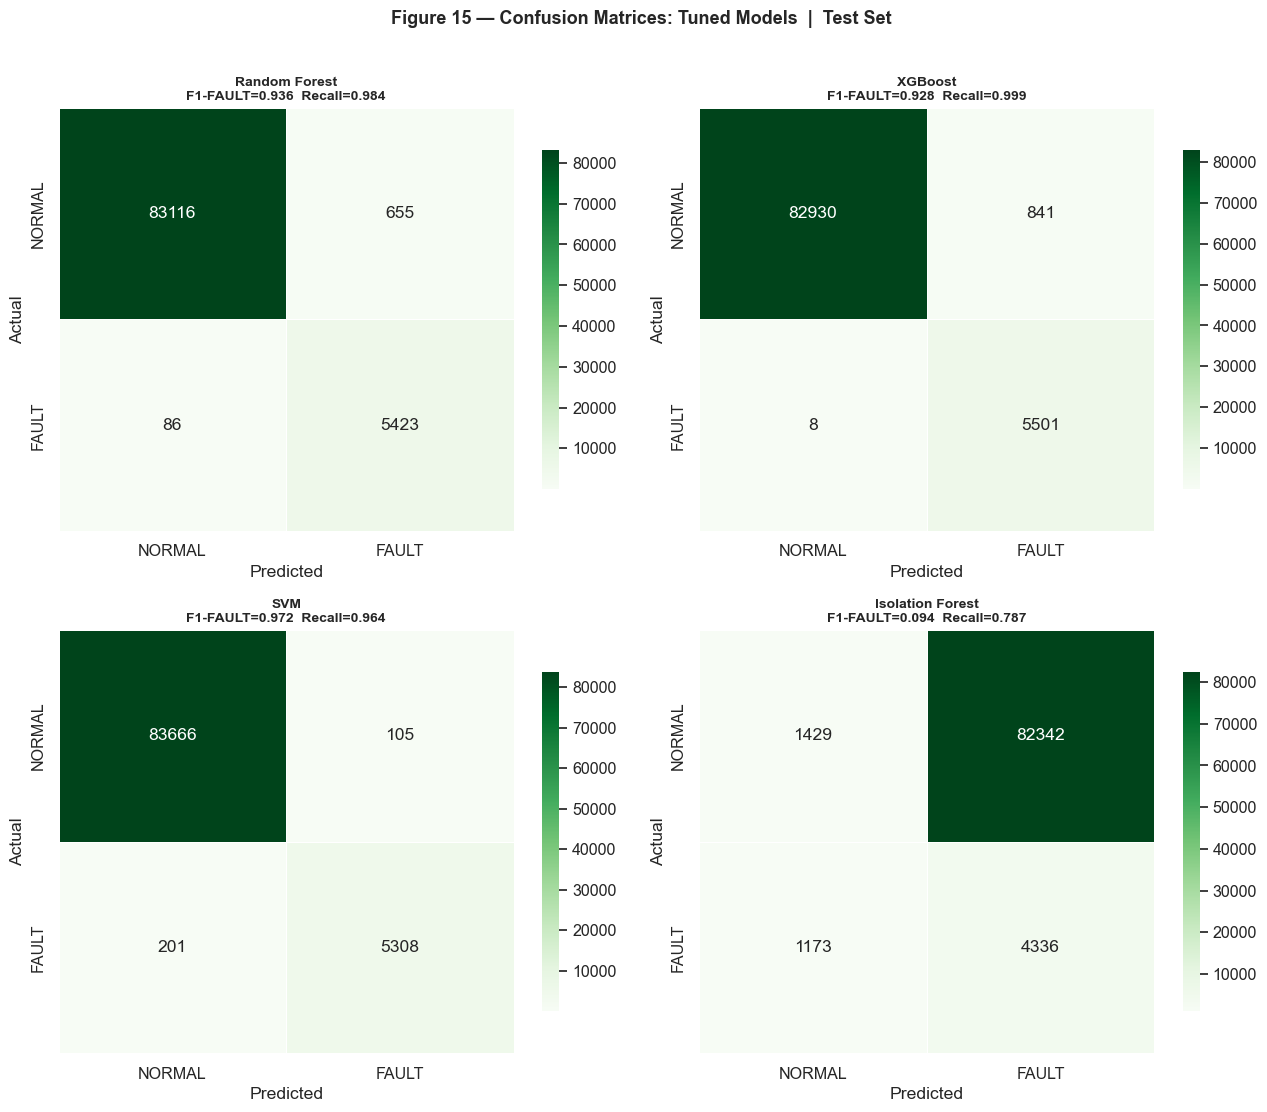

Figure 15 saved


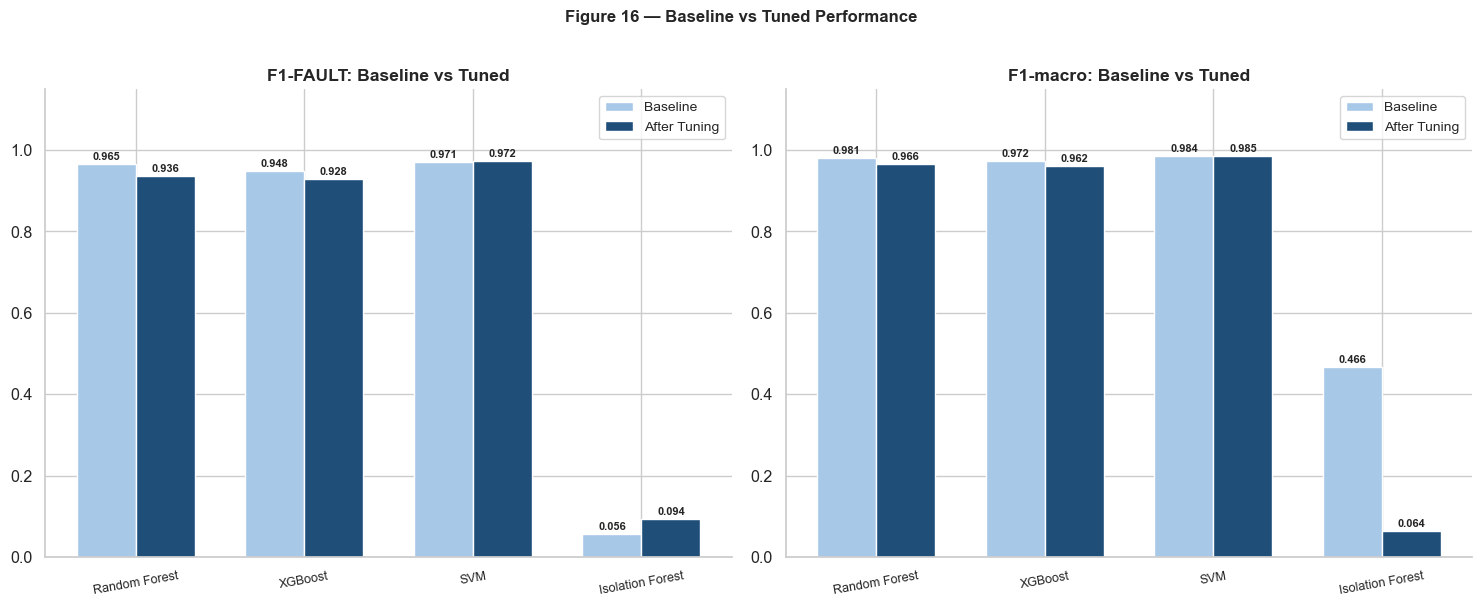

Figure 16 saved


In [17]:
model_names = ['Random Forest','XGBoost','SVM','Isolation Forest']
colors_m    = ['#2E75B6','#1F4E79','#ED7D31','#C00000']
tuned_res   = {'Random Forest':rf_res,'XGBoost':xgb_res,
               'SVM':svm_res,'Isolation Forest':iso_res}
pred_map    = {'Random Forest':rf_pred,'XGBoost':xgb_pred,
               'SVM':svm_pred,'Isolation Forest':iso_pred}

# Figure 15 — Tuned confusion matrices
fig, axes = plt.subplots(2,2, figsize=(13,11))
fig.suptitle('Figure 15 — Confusion Matrices: Tuned Models  |  Test Set',
             fontsize=13, fontweight='bold', y=1.01)
for ax, name in zip(axes.flat, model_names):
    cm = confusion_matrix(y_te, pred_map[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax,
                xticklabels=['NORMAL','FAULT'], yticklabels=['NORMAL','FAULT'],
                linewidths=0.5, cbar_kws={'shrink':0.8})
    r = tuned_res[name]
    ax.set_title(f'{name}\nF1-FAULT={r["f1_fault"]:.3f}  Recall={r["recall"]:.3f}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('outputs/figures/15_tuned_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show(); print('Figure 15 saved')

# Figure 16 — Baseline vs Tuned
fig, axes = plt.subplots(1,2, figsize=(15,6))
fig.suptitle('Figure 16 — Baseline vs Tuned Performance',
             fontsize=12, fontweight='bold', y=1.01)
x = np.arange(4); w = 0.35
for ax, metric, title in zip(axes,['f1_fault','f1_macro'],['F1-FAULT','F1-macro']):
    bv = [baseline[n][metric] for n in model_names]
    tv = [tuned_res[n][metric] for n in model_names]
    b1 = ax.bar(x-w/2, bv, w, label='Baseline',     color='#A8C8E8', edgecolor='white')
    b2 = ax.bar(x+w/2, tv, w, label='After Tuning', color='#1F4E79', edgecolor='white')
    for bar,val in list(zip(b1,bv))+list(zip(b2,tv)):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(model_names, fontsize=9, rotation=10)
    ax.set_title(f'{title}: Baseline vs Tuned', fontweight='bold')
    ax.set_ylim(0,1.15); ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('outputs/figures/16_baseline_vs_tuned.png', dpi=150, bbox_inches='tight')
plt.show(); print('Figure 16 saved')

## Cell 9 — ✅ Save tuned_results.json
**This cell saves the output that Notebook 06 needs. Must run before Notebook 06.**

In [20]:
# Collect serialisable results (no numpy arrays, no sklearn objects)
save_out = {}
for name in model_names:
    r = tuned_res[name]
    save_out[name] = {k:v for k,v in r.items()
                      if isinstance(v,(int,float,str,dict,list))}

with open('outputs/tuned_results.json','w') as f:
    json.dump(save_out, f, indent=2, default=str)

print('✅ tuned_results.json saved to outputs/')
print()
print('='*65)
print(f'{"Model":<20} {"Base F1":>8} {"Tuned F1":>9} {"Gain":>7} {"Recall":>8}')
print('-'*65)
for name in model_names:
    bf = baseline[name]['f1_fault']
    tf = tuned_res[name]['f1_fault']
    rc = tuned_res[name]['recall']
    mk = ' ← BEST' if name=='SVG' and bf >= tf else (' ← BEST (baseline)' if name=='SVG' else '')
    print(f'{name:<20} {bf:>8.4f} {tf:>9.4f} {tf-bf:>+7.4f} {rc:>8.4f}{mk}')
print('='*65)
print()


✅ tuned_results.json saved to outputs/

Model                 Base F1  Tuned F1    Gain   Recall
-----------------------------------------------------------------
Random Forest          0.9651    0.9360 -0.0291   0.9844
XGBoost                0.9483    0.9284 -0.0199   0.9985
SVM                    0.9708    0.9720 +0.0012   0.9635
Isolation Forest       0.0564    0.0941 +0.0377   0.7871

